# Beam past a lossy absorber

In this tutorial we send a beam through a beam-line absorber: a round pipe with a lossy
ceramic ring set into its wall. With the ports open (every port mode open-circuited, as
in the previous lesson) no wave leaves through them, so the real part of the beam
impedance is the power the ring absorbs. We compute that power from the field and compare; with a lossless ring,
the real part vanishes.

**Prerequisites:** [Compute a beam impedance](collimator_impedance.ipynb) and
[Fill a waveguide with lossy material](../models/materials_and_losses.ipynb).

## 1. Build the absorber

### 1.1 Add the beam-line absorber

A pipe of radius 25 mm and length 240 mm. In its middle the wall steps out by 10 mm
over 40 mm to hold a ceramic ring ($\varepsilon_r = 4$, $\tan\delta = 0.5$), so the
beam still sees the 25 mm bore. Dimensions in millimetres.

In [1]:
from cavsim3d.core.em_project import EMProject

proj = EMProject(name="lossy_absorber", base_dir="./simulations", overwrite=True)
proj.create_primitive("bla", name="absorber", R=25, L=240, absorber_length=40,
                      absorber_thickness=10, eps_r=4.0, tan_delta=0.5)
proj.parts["absorber"].get_material("absorber")

✅ Creating new project 'lossy_absorber' at simulations\lossy_absorber


{'eps_r': 4.0, 'mu_r': 1.0, 'sigma': 0.0, 'tan_delta': 0.5}

### 1.2 Add the beam and mesh

In [2]:
proj.add_beam("beam")
proj.generate_mesh(maxh=0.006)

The beam runs on the axis, in vacuum; the ring is off the beam line. Where the
material differs from vacuum the solver adds the difference as a load of its own.

## 2. Solve

The cut-off of the 25 mm pipe is 3.5 GHz (TE11); we stay well below. We read the beam
impedance with the ports open.

In [3]:
cfg = dict(fmin=0.5, fmax=1.5, nsamples=5, nportmodes=3, order=3)
res = proj.fds.solve(**cfg)
fom = proj.fds.fom
z_open = fom.beam_impedance(ports="open")
print("Re Z_par (open ports):", z_open.real.round(4))


Structure Topology
  Type: Single structure
  Domains (1): ['bla']
  Ports (2): ['port1', 'port2']
  Mesh elements: 8883



Assembling Matrices...


Solving port eigenmodes...


Calculating Port Eigenmodes...


	port1 mode 0: TE_11 (cos), kc=73.6474, sigma=+1
	port1 mode 1: TE_11 (sin), kc=73.6474, sigma=+1


	port1 mode 2: TM_01, kc=96.1930, sigma=+1
	port2 mode 0: TE_11 (cos), kc=73.6474, sigma=+1


	port2 mode 1: TE_11 (sin), kc=73.6474, sigma=+1
	port2 mode 2: TM_01, kc=96.1930, sigma=+1
Port eigenmodes complete: 6 total modes



FDS Solve: 0.5000 - 1.5000 GHz, 5 samples


Global Coupled Solve


  Auto solver: 180354 unknowns, a factorisation needs about 2.5 GB of 32.0 GB free -> 'direct'


  
Coupled solve complete: 2 external ports in 37.22s


Re Z_par (open ports): [0.6278 1.063  1.6741 2.5833 4.0035]


The real part grows with frequency, from 0.63 Ω at 0.5 GHz to 4.0 Ω at 1.5 GHz. In a
lossless structure below the cut-off it would be zero.

## 3. Check against the absorbed power

### 3.1 Integrate the losses in the ring

The ring absorbs $P = \frac{1}{2}\int \omega\varepsilon_0\varepsilon_r\tan\delta\,|E|^2\,dV$.
For a current of 1 A, $\mathrm{Re}\,Z_\parallel = 2P$: we integrate
$\omega\varepsilon_0\varepsilon_r\tan\delta\,|E|^2$ over the ring, with
`fom.beam_field(i)`, the beam's total field at sample `i`.

In [4]:
import numpy as np
from ngsolve import InnerProduct, Integrate

from cavsim3d.core.constants import eps0

mesh = proj.fds.mesh
absorbed = []
for i, f in enumerate(fom.frequencies):
    E = fom.beam_field(i)
    loss = 2 * np.pi * f * eps0 * 4.0 * 0.5 * InnerProduct(E, E).real    # |E|^2
    absorbed.append(Integrate(loss, mesh, definedon=mesh.Materials("absorber")))
absorbed = np.array(absorbed)

### 3.2 Compare

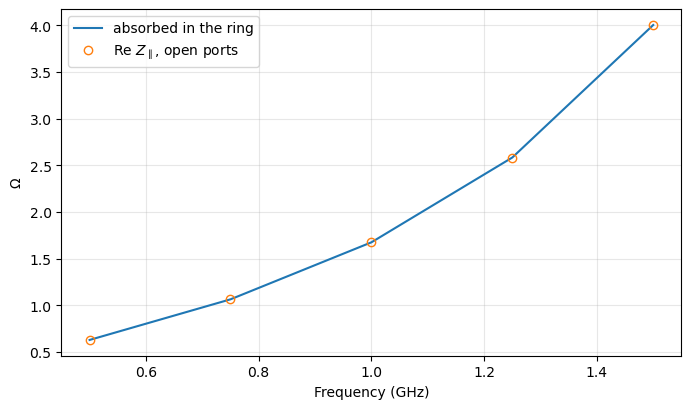

largest relative difference: 4.0e-04


In [5]:
import matplotlib.pyplot as plt

f = fom.frequencies
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(f / 1e9, absorbed, label="absorbed in the ring")
ax.plot(f / 1e9, z_open.real, lw=0, marker="o", mfc="none", label=r"Re $Z_\parallel$, open ports")
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel(r"$\Omega$")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

print(f"largest relative difference: {np.max(np.abs(z_open.real - absorbed) / absorbed):.1e}")

The two agree to 4e-4: what the beam loses, the ring absorbs.

## 4. Make the ring lossless

### 4.1 Change the loss tangent and solve again

The solve sees that a material changed, and solves again.

In [6]:
proj.parts["absorber"].set_materials({"absorber": {"eps_r": 4.0, "tan_delta": 0.0}})
res = proj.fds.solve(**cfg)
z_lossless = proj.fds.fom.beam_impedance(ports="open")
print("Re Z_par (open ports):", z_lossless.real.round(5))


FDS Solve: 0.5000 - 1.5000 GHz, 5 samples


Global Coupled Solve


  Auto solver: 180354 unknowns, a factorisation needs about 1.5 GB of 32.3 GB free -> 'direct'


  
Coupled solve complete: 2 external ports in 18.59s


Re Z_par (open ports): [0.e+00 0.e+00 1.e-05 1.e-05 2.e-05]


Without loss the real part is at most 2e-5 Ω: zero, up to the discretisation.

## What we did

We sent a beam through a pipe with a lossy ring in its wall, and found that the real
part of the beam impedance is the power the ring absorbs, as long as no wave leaves
through the ports. Without loss it vanishes.

**Next:** [Join parts with a beam](beam_through_parts.ipynb).

**Background:** [Beam excitation](../../theory/beam.md), §9.6 for the load of a material
off the beam line.